In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:
data = data.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.914760,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.974660,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.805840,5.078981,6.487988,6.115845,4.977656,5.474359,5.221860,7.239703,3.538015,...,10.480460,5.022233,4.247290,4.857951,4.822149,4.373500,6.082677,6.200747,8.470901,4.877400
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.880500,3.793164,3.881190,7.631016,4.571990,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.705530,5.690952,6.502288,5.733583,4.652300,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.790120,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.938070,6.867025,4.780228,4.200692,7.120193,7.008641,5.275480,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.425790,4.721240,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.206010,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.385460,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
# train-test split evaluation of xgboost model
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# load data

# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
# fit model no training data
model = XGBClassifier()
model.fit(X_train, y_train)
# make predictions for test data
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]
# evaluate predictions
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 100.00%


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    eta=0.1,           # lower learning rate
    n_estimators=200   # more trees to compensate
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print(f"Fold Accuracies : {[f'{s*100:.2f}%' for s in scores]}")
print(f"Mean Accuracy   : {scores.mean()*100:.2f}%")
print(f"Std Deviation   : {scores.std()*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Fold Accuracies : ['86.67%', '100.00%', '100.00%', '100.00%', '100.00%']
Mean Accuracy   : 97.33%
Std Deviation   : 5.33%


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],          # 5 values
    'n_estimators': [100, 200,300,400,500],                     # 2 values
}

# Stratified K-Fold inside GridSearch
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1       # uses all CPU cores
)

grid_search.fit(X, y)

# Results
print(f"Best Params   : {grid_search.best_params_}")
print(f"Best Accuracy : {grid_search.best_score_*100:.2f}%")

# Full results as a dataframe
results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_eta', 'param_n_estimators', 'mean_test_score', 'rank_test_score']]
      .sort_values('rank_test_score'))

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best Params   : {'eta': 0.2, 'n_estimators': 100}
Best Accuracy : 97.50%
    param_eta  param_n_estimators  mean_test_score  rank_test_score
15       0.20                 100         0.975000                1
22       0.30                 300         0.975000                1
21       0.30                 200         0.975000                1
20       0.30                 100         0.975000                1
19       0.20                 500         0.975000                1
18       0.20                 400         0.975000                1
17       0.20                 300         0.975000                1
24       0.30                 500         0.975000                1
23       0.30                 400         0.975000                1
16       0.20                 200         0.975000                1
5        0.05                 100         0.962500               11
7        0.05                 300         0.9625

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:48:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results.to_csv("xgboost_cv.csv")

In [ ]:
import joblib

In [ ]:
best_model = grid_search.best_estimator_

# Method 1: Using joblib (Recommended)
joblib.dump(best_model, '10kfold_only_xgboost_best_model.pkl')
print("✅ Model saved as 'xgboost_best_model.pkl' using joblib")



✅ Model saved as 'xgboost_best_model.pkl' using joblib


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd
import joblib
from datetime import datetime

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
}

# Scoring dictionary (suitable for most journals)
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'mcc': 'matthews_corrcoef',
    'neg_log_loss': 'neg_log_loss'
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',           # Best model is chosen based on ROC-AUC
    cv=skf,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*60)
print("🏆 BEST PARAMETERS")
print("="*60)
print(grid_search.best_params_)

print(f"\nBest accuracy: {grid_search.best_score_:.4f}")

# Full results
results = pd.DataFrame(grid_search.cv_results_)

# Display top results sorted by ROC-AUC
cols = ['param_eta', 'param_n_estimators']
for metric in scoring_dict.keys():
    cols.append(f'mean_test_{metric}')

print("\n=== Top 5 Models (sorted by accuracy) ===")
top_results = results[cols].sort_values('mean_test_roc_auc', ascending=False).head(5).round(4)
print(top_results)

# Save full results to CSV (useful for journal paper)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results[cols].to_csv(f'gridsearch_results_{timestamp}.csv', index=False)
print(f"\n📊 Full results saved to 'gridsearch_results_{timestamp}.csv'")

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_

# Save using joblib (recommended)
joblib.dump(best_model, f'cv_xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best model saved as 'xgboost_best_model_{timestamp}.pkl'")


print("\n🎉 Done! Best model is ready for inference.")

Fitting 10 folds for each of 25 candidates, totalling 250 fits
🏆 BEST PARAMETERS
{'eta': 0.01, 'n_estimators': 100}

Best accuracy: 0.9417

=== Top 5 Models (sorted by accuracy) ===
   param_eta  param_n_estimators  mean_test_accuracy  mean_test_roc_auc  \
0       0.01                 100              0.9417              0.975   
1       0.01                 200              0.9167              0.975   
2       0.01                 300              0.9167              0.975   
3       0.01                 400              0.9167              0.975   
4       0.01                 500              0.9167              0.975   

   mean_test_f1  mean_test_precision  mean_test_recall  mean_test_f1_macro  \
0        0.9467               0.9667              0.95              0.9400   
1        0.9267               0.9333              0.95              0.9133   
2        0.9267               0.9333              0.95              0.9133   
3        0.9267               0.9333              0.95 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5 KFOLD ONLY


In [ ]:

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/5kfold_only_xgboost_best_model.pkl')
print(f"Model expects {best_model.n_features_in_} features")

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Model expects 49 features
Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.5429
ROC-AUC              : 0.5200
AUCPRC               : 0.6170
Avg Precision        : 0.6170
F1 Score             : 0.6800
F1 Macro             : 0.4400
F1 Weighted          : 0.4743
Precision            : 0.5667
Recall               : 0.8500
MCC                  : -0.0236

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.4000    0.1333    0.2000        15
         1.0     0.5667    0.8500    0.6800        20

    accuracy                         0.5429        35
   macro avg     0.4833    0.4917    0.4400        35
weighted avg     0.4952    0.5429    0.4743        35


✅ Metrics saved as 'validation_metrics_20260528_1047.csv'


10KFOLD ONLY

In [ ]:

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/10kfold_only_xgboost_best_model.pkl')
print(f"Model expects {best_model.n_features_in_} features")

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Model expects 49 features
Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.4857
ROC-AUC              : 0.4850
AUCPRC               : 0.5985
Avg Precision        : 0.5985
F1 Score             : 0.6250
F1 Macro             : 0.4034
F1 Weighted          : 0.4351
Precision            : 0.5357
Recall               : 0.7500
MCC                  : -0.1443

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.2857    0.1333    0.1818        15
         1.0     0.5357    0.7500    0.6250        20

    accuracy                         0.4857        35
   macro avg     0.4107    0.4417    0.4034        35
weighted avg     0.4286    0.4857    0.4351        35


✅ Metrics saved as 'validation_metrics_20260528_1049.csv'


In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [ ]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [ ]:
data = merged.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y_val = y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X_val= X


10 repeat and 10 stratified k fold

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
from datetime import datetime

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'mcc': 'matthews_corrcoef',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,        # 3 repeats = 30 total folds (recommended)
    random_state=42
)

# Grid Search with RepeatedStratifiedKFold
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',           # You can change to 'roc_auc' or 'mcc'
    cv=rskf,                    # ← Changed to RepeatedStratifiedKFold
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)

print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

# Full results
results = pd.DataFrame(grid_search.cv_results_)

# Display top results sorted by ROC-AUC
cols = ['param_eta', 'param_n_estimators']
for metric in scoring_dict.keys():
    cols.append(f'mean_test_{metric}')

print("\n=== Top 5 Models (sorted by accuracy) ===")
top_results = results[cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top_results)

# Save full results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results[cols].to_csv(f'gridsearch_results_{timestamp}.csv', index=False)
print(f"\n📊 Full results saved to 'gridsearch_results_{timestamp}.csv'")

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_

joblib.dump(best_model, f'10xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best model saved as 'xgboost_best_model_{timestamp}.pkl'")

best_model.save_model(f'xgboost_best_model_{timestamp}.json')
print(f"✅ Model also saved as 'xgboost_best_model_{timestamp}.json'")

print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 100 folds for each of 25 candidates, totalling 2500 fits
🏆 BEST PARAMETERS
{'eta': 0.01, 'n_estimators': 100}

Best Accuracy : 0.9267

=== Top 5 Models (sorted by ROC-AUC) ===
    param_eta  param_n_estimators  mean_test_accuracy  mean_test_roc_auc  \
0        0.01                 100              0.9267             0.9525   
17       0.20                 300              0.9117             0.9625   
18       0.20                 400              0.9117             0.9625   
16       0.20                 200              0.9117             0.9625   
19       0.20                 500              0.9117             0.9625   

    mean_test_f1  mean_test_precision  mean_test_recall  mean_test_f1_macro  \
0         0.9363               0.9483             0.950              0.9110   
17        0.9113               0.9233             0.925              0.8927   
18        0.9113               0.9233             0.925              0.8927   
16        0.9113               0.9233      

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:02:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


validation
10 and 10

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/10xgboost_best_model_20260528_1102.pkl')
print(f"Model expects {best_model.n_features_in_} features")

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Model expects 49 features
Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.9714
ROC-AUC              : 1.0000
AUCPRC               : 1.0000
Avg Precision        : 1.0000
F1 Score             : 0.9744
F1 Macro             : 0.9711
F1 Weighted          : 0.9715
Precision            : 1.0000
Recall               : 0.9500
MCC                  : 0.9437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.9375    1.0000    0.9677        15
         1.0     1.0000    0.9500    0.9744        20

    accuracy                         0.9714        35
   macro avg     0.9688    0.9750    0.9711        35
weighted avg     0.9732    0.9714    0.9715        35


✅ Metrics saved as 'validation_metrics_20260528_1105.csv'


10 repeat and 5 stratified k fold

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
from datetime import datetime

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'mcc': 'matthews_corrcoef',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,        # 3 repeats = 30 total folds (recommended)
    random_state=42
)

# Grid Search with RepeatedStratifiedKFold
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',           # You can change to 'roc_auc' or 'mcc'
    cv=rskf,                    # ← Changed to RepeatedStratifiedKFold
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)

print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

# Full results
results = pd.DataFrame(grid_search.cv_results_)

# Display top results sorted by ROC-AUC
cols = ['param_eta', 'param_n_estimators']
for metric in scoring_dict.keys():
    cols.append(f'mean_test_{metric}')

print("\n=== Top 5 Models (sorted by ROC-AUC) ===")
top_results = results[cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top_results)

# Save full results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results[cols].to_csv(f'gridsearch_results_{timestamp}.csv', index=False)
print(f"\n📊 Full results saved to 'gridsearch_results_{timestamp}.csv'")

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_

joblib.dump(best_model, f'5r_xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best model saved as 'xgboost_best_model_{timestamp}.pkl'")

best_model.save_model(f'xgboost_best_model_{timestamp}.json')
print(f"✅ Model also saved as 'xgboost_best_model_{timestamp}.json'")

print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 50 folds for each of 25 candidates, totalling 1250 fits
🏆 BEST PARAMETERS
{'eta': 0.01, 'n_estimators': 100}

Best Accuracy : 0.9267

=== Top 5 Models (sorted by ROC-AUC) ===
    param_eta  param_n_estimators  mean_test_accuracy  mean_test_roc_auc  \
0        0.01                 100              0.9267              0.940   
17       0.20                 300              0.9167              0.955   
18       0.20                 400              0.9167              0.955   
16       0.20                 200              0.9167              0.955   
19       0.20                 500              0.9167              0.955   

    mean_test_f1  mean_test_precision  mean_test_recall  mean_test_f1_macro  \
0         0.9360                 0.95              0.95              0.9107   
17        0.9127                 0.93              0.92              0.9007   
18        0.9127                 0.93              0.92              0.9007   
16        0.9127                 0.93       

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:07:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


validation
10 and 5

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/5r_xgboost_best_model_20260528_1107.pkl')
print(f"Model expects {best_model.n_features_in_} features")

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Model expects 49 features
Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.9714
ROC-AUC              : 1.0000
AUCPRC               : 1.0000
Avg Precision        : 1.0000
F1 Score             : 0.9744
F1 Macro             : 0.9711
F1 Weighted          : 0.9715
Precision            : 1.0000
Recall               : 0.9500
MCC                  : 0.9437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.9375    1.0000    0.9677        15
         1.0     1.0000    0.9500    0.9744        20

    accuracy                         0.9714        35
   macro avg     0.9688    0.9750    0.9711        35
weighted avg     0.9732    0.9714    0.9715        35


✅ Metrics saved as 'validation_metrics_20260528_1109.csv'


10 repeat and 3 stratified k fold

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
from datetime import datetime

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'mcc': 'matthews_corrcoef',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,        # 3 repeats = 30 total folds (recommended)
    random_state=42
)

# Grid Search with RepeatedStratifiedKFold
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',           # You can change to 'roc_auc' or 'mcc'
    cv=rskf,                    # ← Changed to RepeatedStratifiedKFold
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)

print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

# Full results
results = pd.DataFrame(grid_search.cv_results_)

# Display top results sorted by ROC-AUC
cols = ['param_eta', 'param_n_estimators']
for metric in scoring_dict.keys():
    cols.append(f'mean_test_{metric}')

print("\n=== Top 5 Models (sorted by ROC-AUC) ===")
top_results = results[cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top_results)

# Save full results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results[cols].to_csv(f'gridsearch_results_{timestamp}.csv', index=False)
print(f"\n📊 Full results saved to 'gridsearch_results_{timestamp}.csv'")

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_

joblib.dump(best_model, f'3r_xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best model saved as 'xgboost_best_model_{timestamp}.pkl'")

best_model.save_model(f'xgboost_best_model_{timestamp}.json')
print(f"✅ Model also saved as 'xgboost_best_model_{timestamp}.json'")

print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 30 folds for each of 25 candidates, totalling 750 fits
🏆 BEST PARAMETERS
{'eta': 0.01, 'n_estimators': 100}

Best Accuracy : 0.9333

=== Top 5 Models (sorted by ROC-AUC) ===
    param_eta  param_n_estimators  mean_test_accuracy  mean_test_roc_auc  \
0        0.01                 100              0.9333             0.9583   
17       0.20                 300              0.9250             0.9667   
18       0.20                 400              0.9250             0.9667   
16       0.20                 200              0.9250             0.9667   
19       0.20                 500              0.9250             0.9667   

    mean_test_f1  mean_test_precision  mean_test_recall  mean_test_f1_macro  \
0         0.9422               0.9611            0.9500              0.9267   
17        0.9133               0.9333            0.9167              0.9178   
18        0.9133               0.9333            0.9167              0.9178   
16        0.9133               0.9333        

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


validation
10 and 3

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/3r_xgboost_best_model_20260528_1116.pkl')
print(f"Model expects {best_model.n_features_in_} features")

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Model expects 49 features
Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.9714
ROC-AUC              : 1.0000
AUCPRC               : 1.0000
Avg Precision        : 1.0000
F1 Score             : 0.9744
F1 Macro             : 0.9711
F1 Weighted          : 0.9715
Precision            : 1.0000
Recall               : 0.9500
MCC                  : 0.9437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.9375    1.0000    0.9677        15
         1.0     1.0000    0.9500    0.9744        20

    accuracy                         0.9714        35
   macro avg     0.9688    0.9750    0.9711        35
weighted avg     0.9732    0.9714    0.9715        35


✅ Metrics saved as 'validation_metrics_20260528_1116.csv'


10 repeat and 2 stratified k fold

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
from datetime import datetime

# Define model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'mcc': 'matthews_corrcoef',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,        # 3 repeats = 30 total folds (recommended)
    random_state=42
)

# Grid Search with RepeatedStratifiedKFold
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',           # You can change to 'roc_auc' or 'mcc'
    cv=rskf,                    # ← Changed to RepeatedStratifiedKFold
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)

print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

# Full results
results = pd.DataFrame(grid_search.cv_results_)

# Display top results sorted by ROC-AUC
cols = ['param_eta', 'param_n_estimators']
for metric in scoring_dict.keys():
    cols.append(f'mean_test_{metric}')

print("\n=== Top 5 Models (sorted by accuracy) ===")
top_results = results[cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top_results)

# Save full results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results[cols].to_csv(f'gridsearch_results_{timestamp}.csv', index=False)
print(f"\n📊 Full results saved to 'gridsearch_results_{timestamp}.csv'")

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_

joblib.dump(best_model, f'2r_xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best model saved as 'xgboost_best_model_{timestamp}.pkl'")

best_model.save_model(f'xgboost_best_model_{timestamp}.json')
print(f"✅ Model also saved as 'xgboost_best_model_{timestamp}.json'")

print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 20 folds for each of 25 candidates, totalling 500 fits
🏆 BEST PARAMETERS
{'eta': 0.3, 'n_estimators': 100}

Best Accuracy : 0.9875

=== Top 5 Models (sorted by accuracy) ===
    param_eta  param_n_estimators  mean_test_accuracy  mean_test_roc_auc  \
21        0.3                 200              0.9875                1.0   
24        0.3                 500              0.9875                1.0   
23        0.3                 400              0.9875                1.0   
22        0.3                 300              0.9875                1.0   
20        0.3                 100              0.9875                1.0   

    mean_test_f1  mean_test_precision  mean_test_recall  mean_test_f1_macro  \
21          0.99               0.9833               1.0              0.9867   
24          0.99               0.9833               1.0              0.9867   
23          0.99               0.9833               1.0              0.9867   
22          0.99               0.9833        

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:16:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best CV Model saved as '2r_xgboost_best_model_20260528_1422.pkl'

🎉 Training completed!
Best CV Accuracy: 0.9875


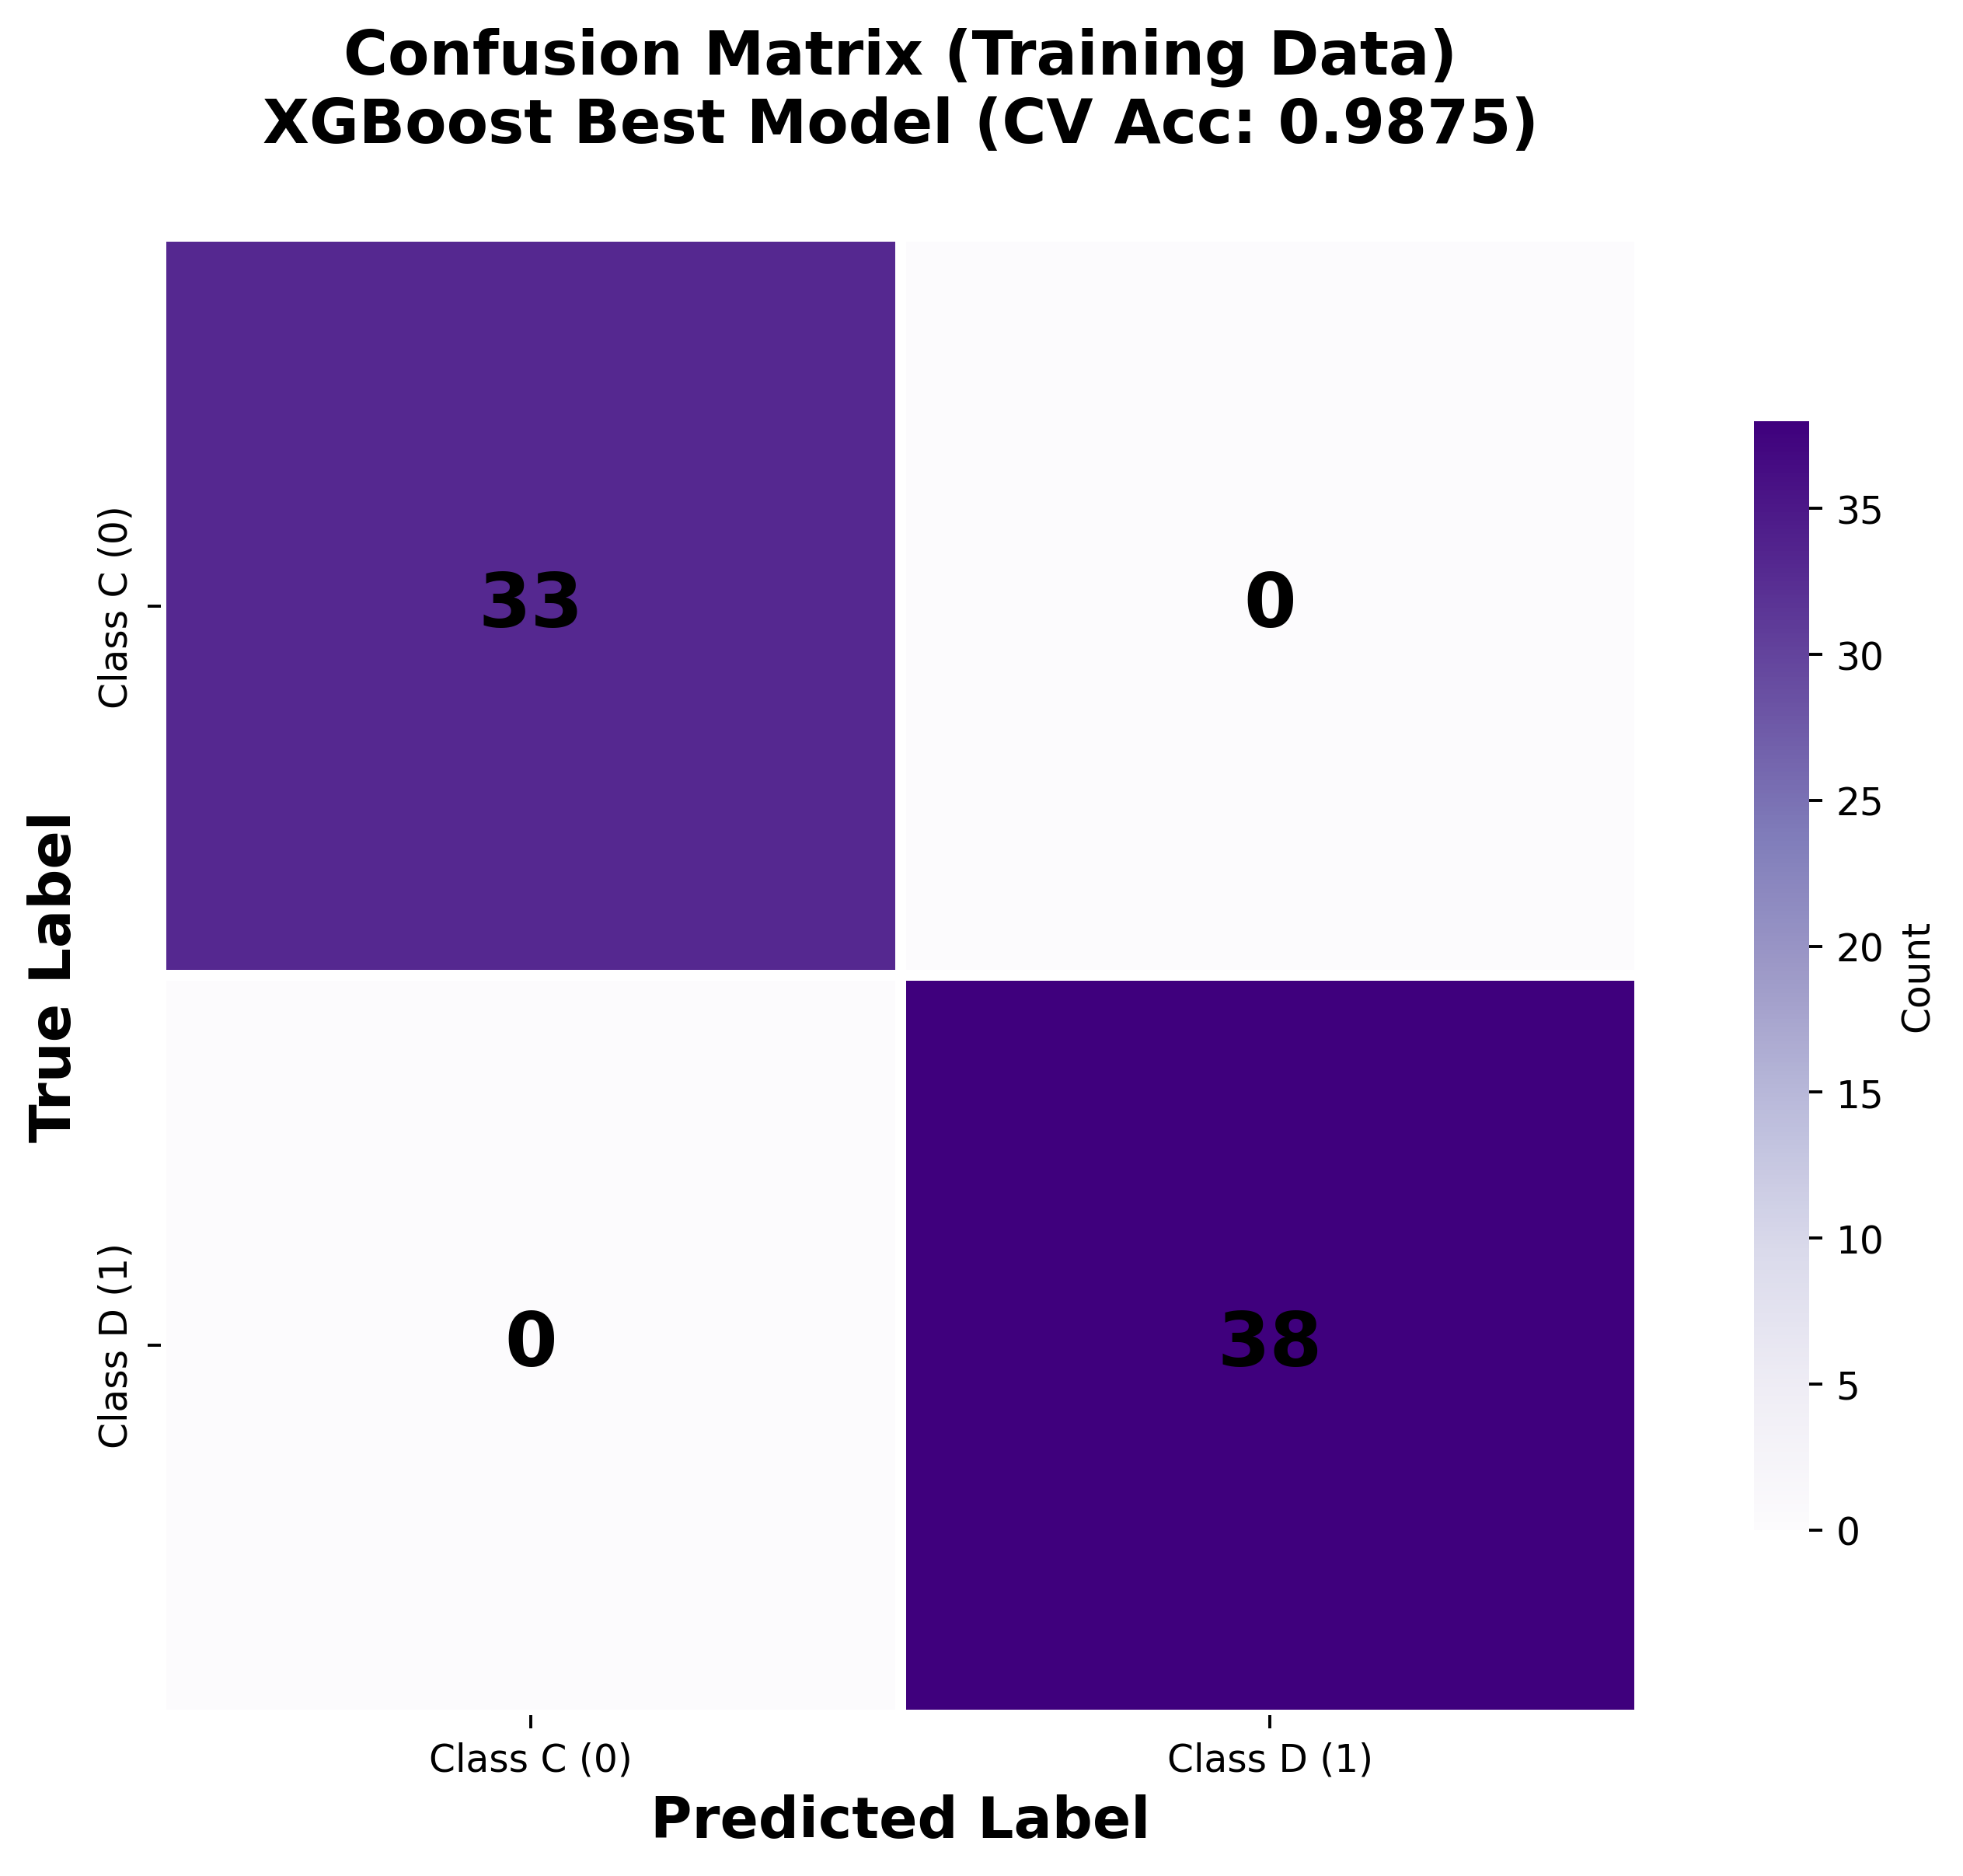

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260528_142404.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 0.9875
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [ ]:

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
joblib.dump(best_model, f'2r_xgboost_best_model_{timestamp}.pkl')
print(f"✅ Best CV Model saved as '2r_xgboost_best_model_{timestamp}.pkl'")

best_model.save_model(f'xgboost_best_model_{timestamp}.json')

print("\n🎉 Training completed!")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")


Calculating SHAP values (this may take a moment)...


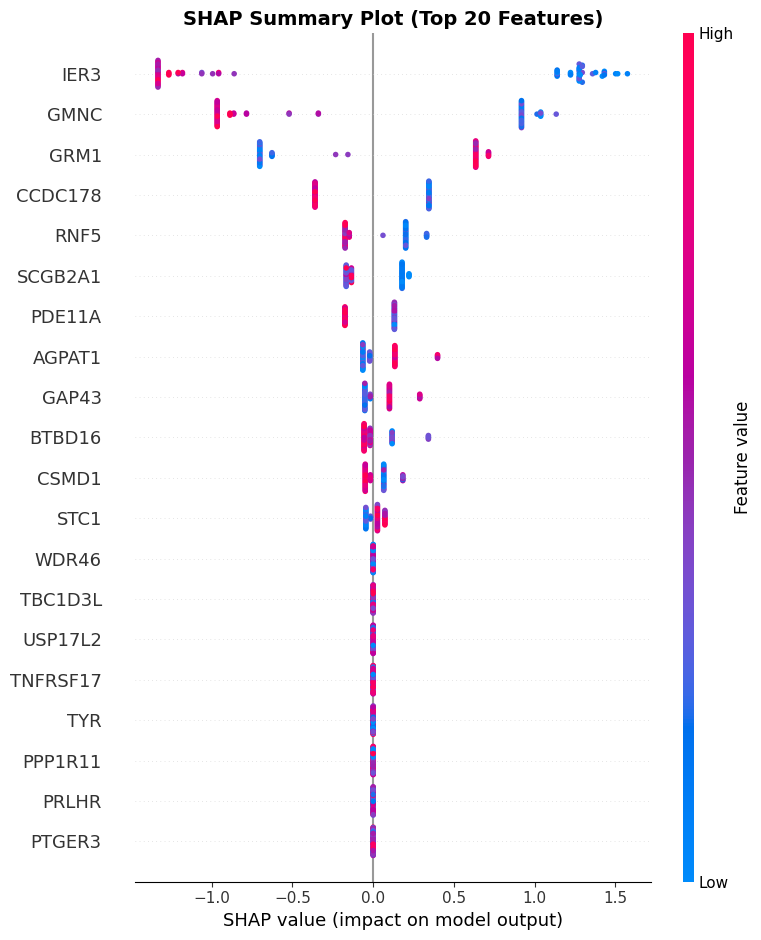

✅ SHAP summary plot saved as 'shap_summary_20260528_1128.png'


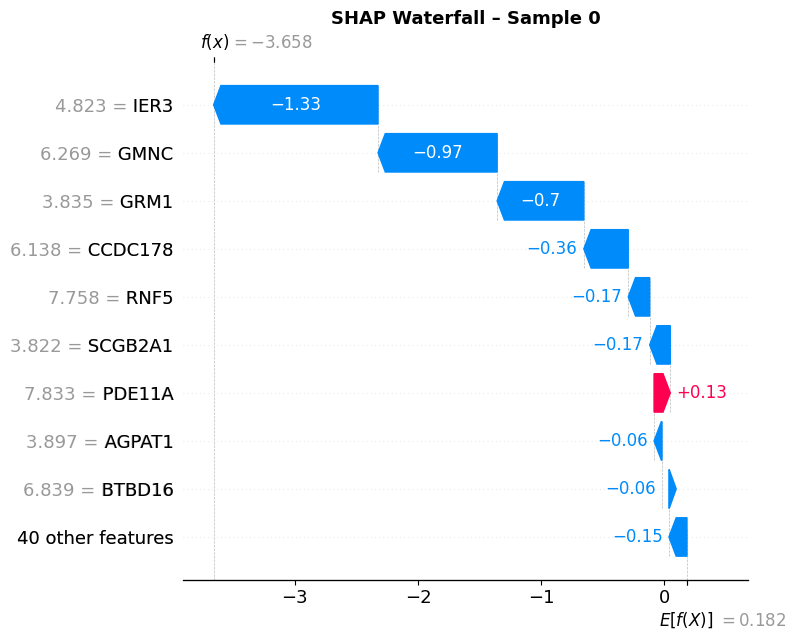

✅ SHAP waterfall saved as 'shap_waterfall_20260528_1128.png'
✅ SHAP importance saved as 'shap_importance_20260528_1128.csv'

Top 10 SHAP Features:
Feature  Mean_Abs_SHAP
   IER3       1.276862
   GMNC       0.915057
   GRM1       0.655863
CCDC178       0.352506
   RNF5       0.192779
SCGB2A1       0.167698
 PDE11A       0.149381
 AGPAT1       0.104888
  GAP43       0.088325
 BTBD16       0.078940


In [ ]:

# ==========================
# 9. SHAP VALUES
# ==========================
import shap
import numpy as np

print("\nCalculating SHAP values (this may take a moment)...")

X_array      = X.values.astype(np.float32)
feature_names = list(X.columns)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_array)

# --- 9a. SHAP Summary Plot (Beeswarm) ---
plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP summary plot saved as 'shap_summary_{timestamp}.png'")



# --- 9c. SHAP Waterfall (first sample) ---
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap_exp = shap.Explanation(
    values        = shap_values[0],
    base_values   = base_val,
    data          = X_array[0],
    feature_names = feature_names
)
plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ SHAP waterfall saved as 'shap_waterfall_{timestamp}.png'")

# --- 9d. SHAP Feature Importance CSV ---
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{timestamp}.csv', index=False)
print(f"✅ SHAP importance saved as 'shap_importance_{timestamp}.csv'")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

validation
10 and 2

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [ ]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [ ]:
data = merged.T

# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

In [ ]:
import pickle
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

# ==========================
# 1. LOAD MODEL
# ==========================
best_model = joblib.load('/content/2r_xgboost_best_model_20260528_1117.pkl')
model = joblib.load('/content/2r_xgboost_best_model_20260528_1117.pkl')

# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.9714
ROC-AUC              : 1.0000
AUCPRC               : 1.0000
Avg Precision        : 1.0000
F1 Score             : 0.9744
F1 Macro             : 0.9711
F1 Weighted          : 0.9715
Precision            : 1.0000
Recall               : 0.9500
MCC                  : 0.9437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9375    1.0000    0.9677        15
           1     1.0000    0.9500    0.9744        20

    accuracy                         0.9714        35
   macro avg     0.9688    0.9750    0.9711        35
weighted avg     0.9732    0.9714    0.9715        35


✅ Metrics saved as 'validation_metrics_20260624_1410.csv'


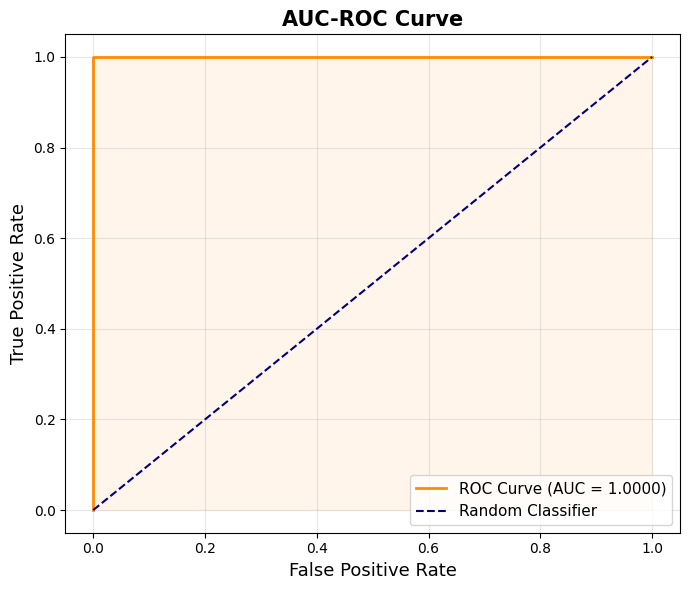

✅ AUC-ROC curve saved as 'aucroc_curve.png'


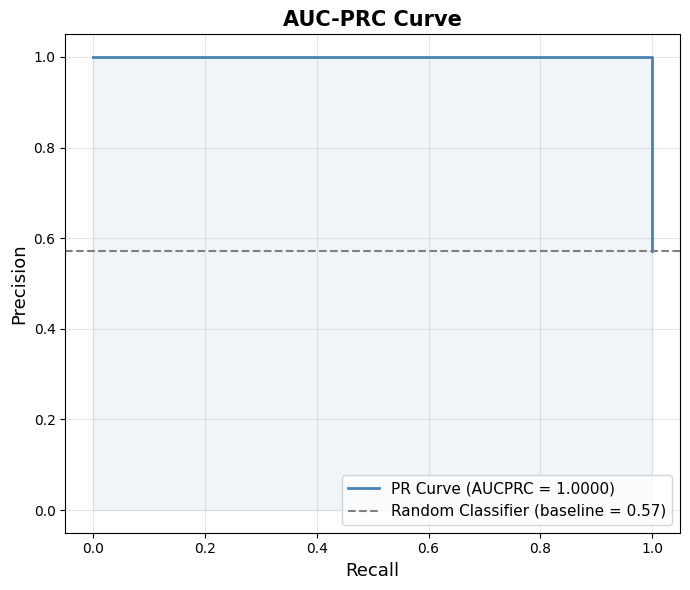

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")



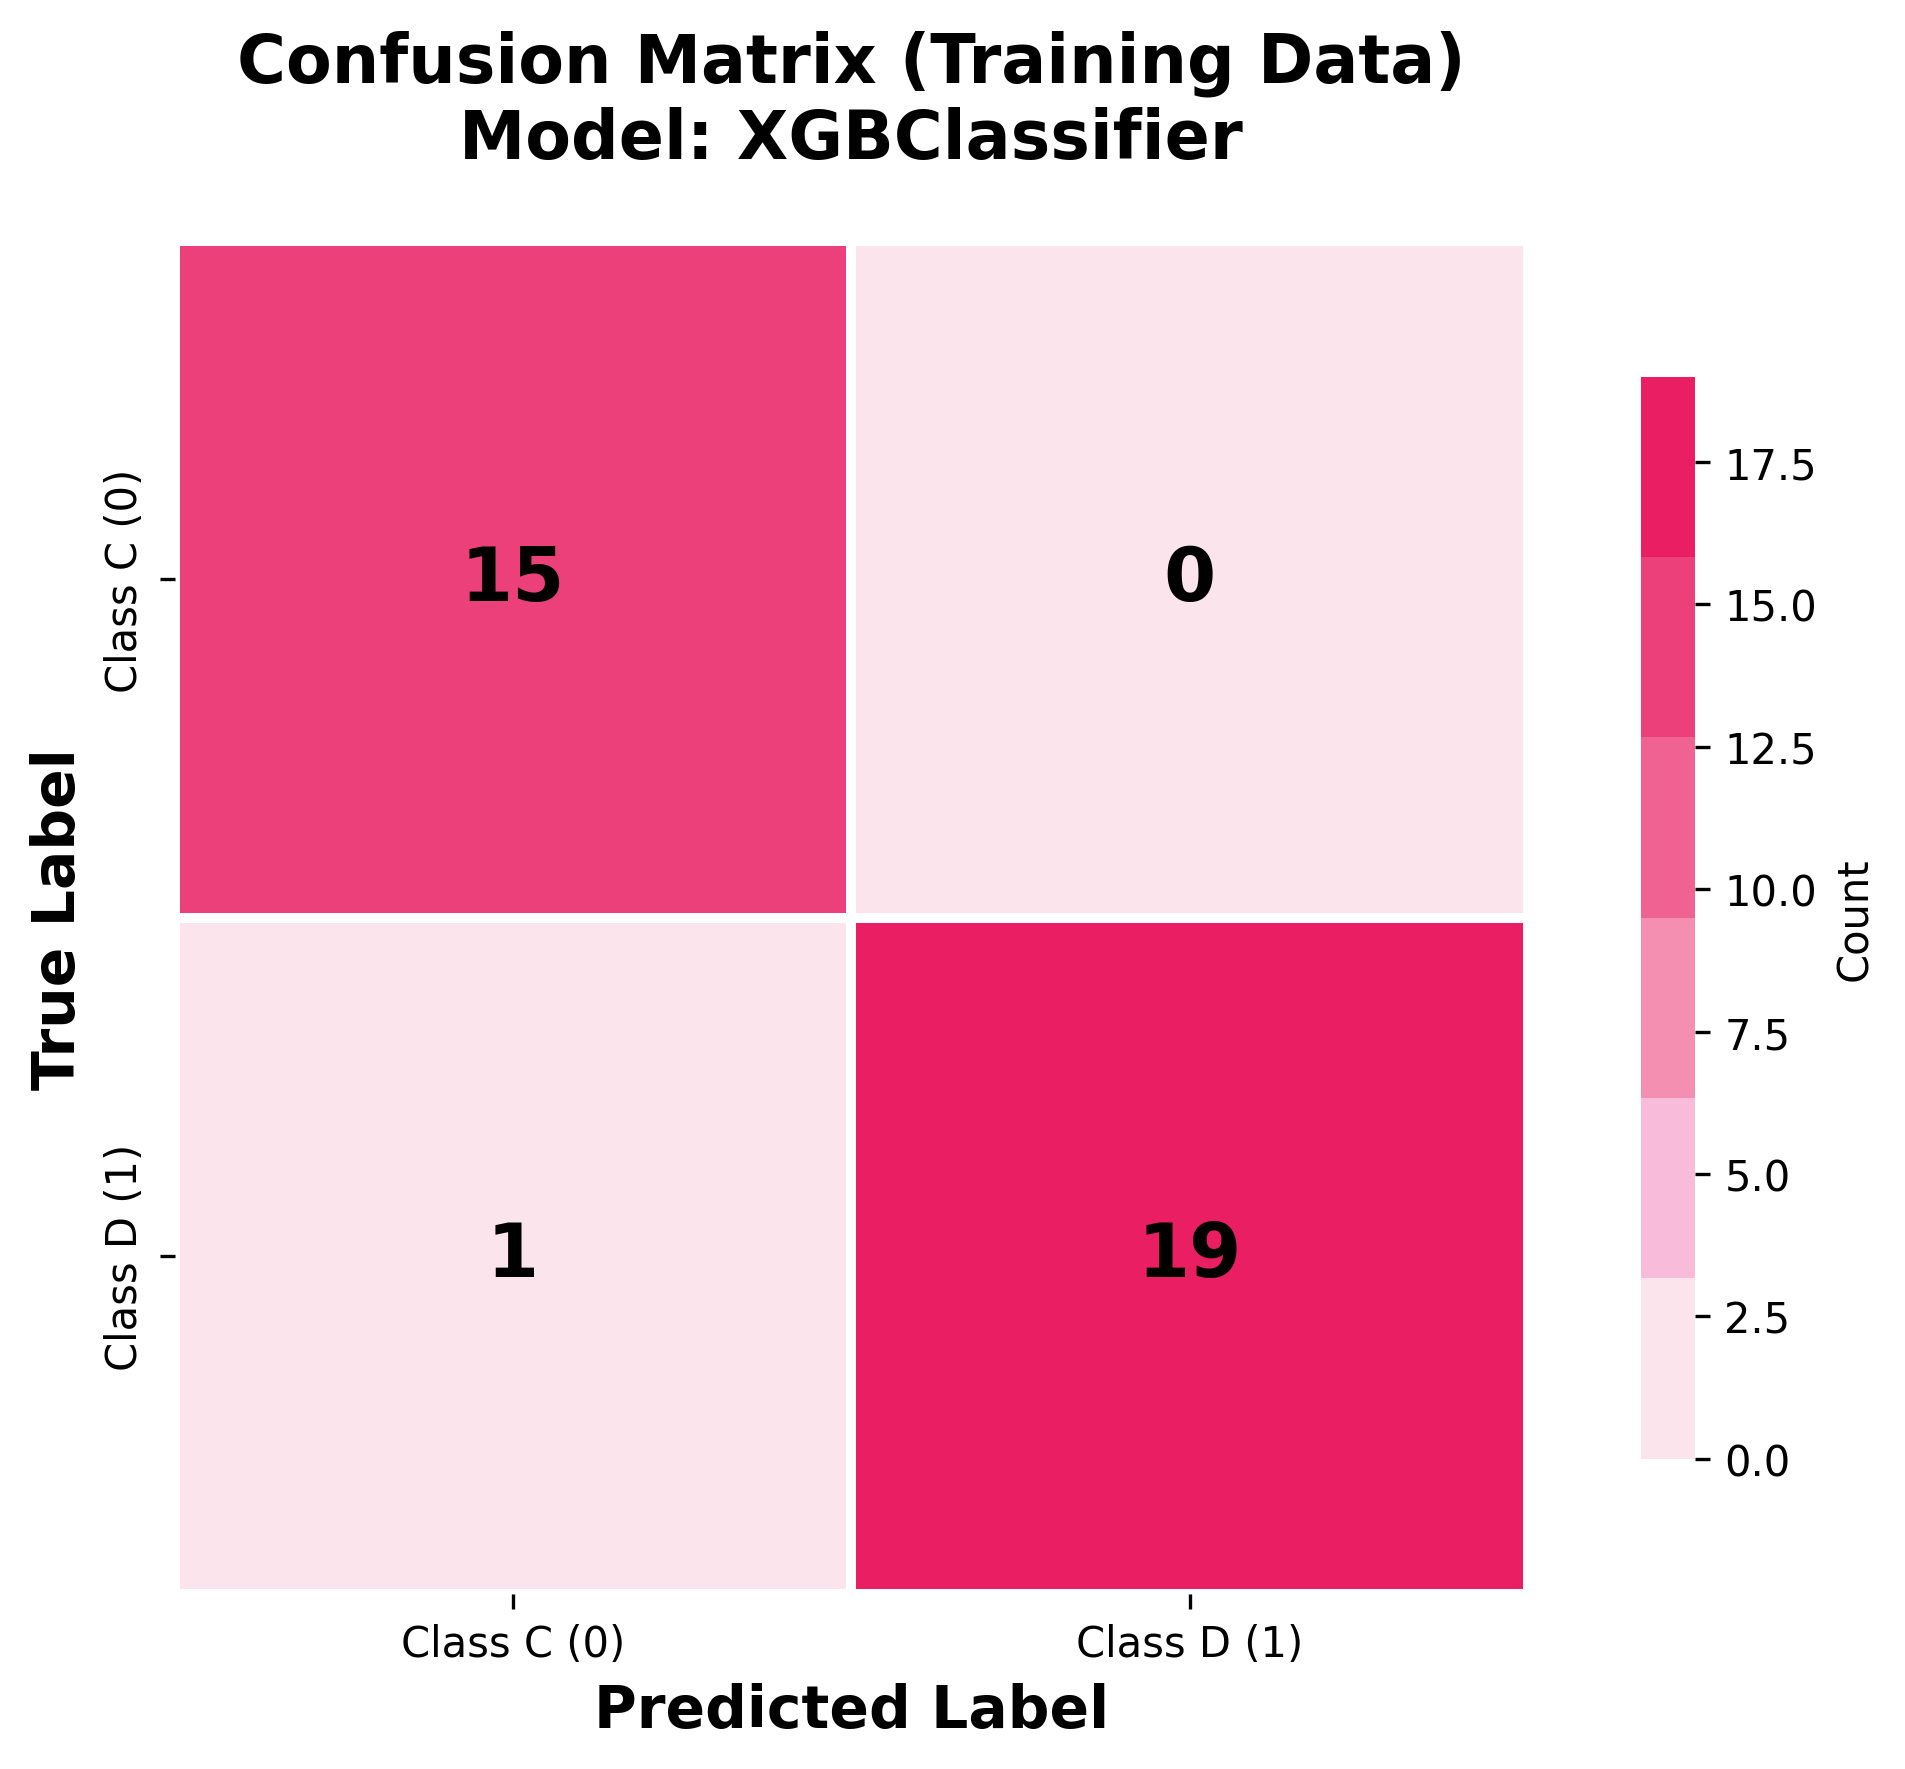


✅ Confusion matrix saved as 'confusion_matrix_20260623_211944.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.9714
Precision: 1.0000
Recall:    0.9500
F1-Score:  0.9744
MCC:       0.9437

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                15             0
True Class D                 1            19


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel: {type(model).__name__}',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_{timestamp}.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")